#Random forest

##1. Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/content/glass.csv")
print(df.head())

# Clean column names
df.columns = df.columns.str.strip()

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


##2. EDA (Exploratory Data Analysis)

In [ ]:
print(df.info())
print(df.describe())

# Missing values
print("Missing Values:\n", df.isnull().sum())

# Duplicate check
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      15 non-null     float64
 1   Na      15 non-null     float64
 2   Mg      15 non-null     float64
 3   Al      15 non-null     float64
 4   Si      15 non-null     float64
 5   K       15 non-null     float64
 6   Ca      15 non-null     float64
 7   Ba      15 non-null     float64
 8   Fe      15 non-null     float64
 9   Type    15 non-null     int64  
dtypes: float64(9), int64(1)
memory usage: 1.3 KB
None
              RI         Na         Mg         Al         Si          K  \
count  15.000000  15.000000  15.000000  15.000000  15.000000  15.000000   
mean    1.517460  13.275333   3.644667   1.317333  72.844667   0.536667   
std     0.001339   0.401032   0.243013   0.166453   0.420711   0.149984   
min     1.515710  12.720000   3.430000   1.050000  71.780000   0.060000   
25%     1.516800  12.94

###observations:
#####No missing values
#####All features are numerical
#####Target variable = Type

#3. Data Visualization

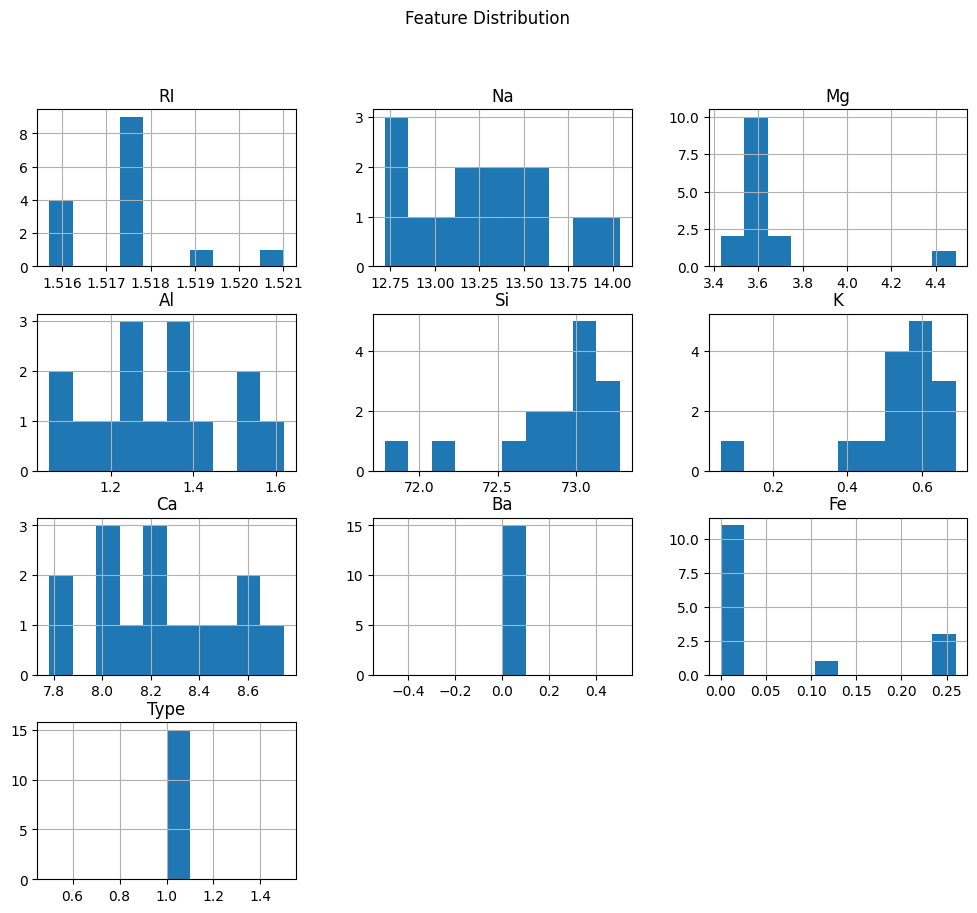

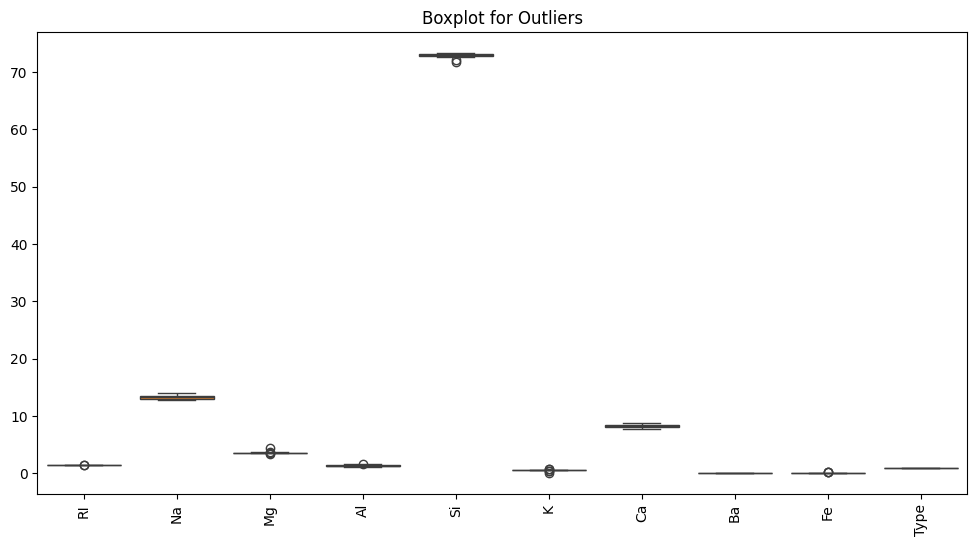

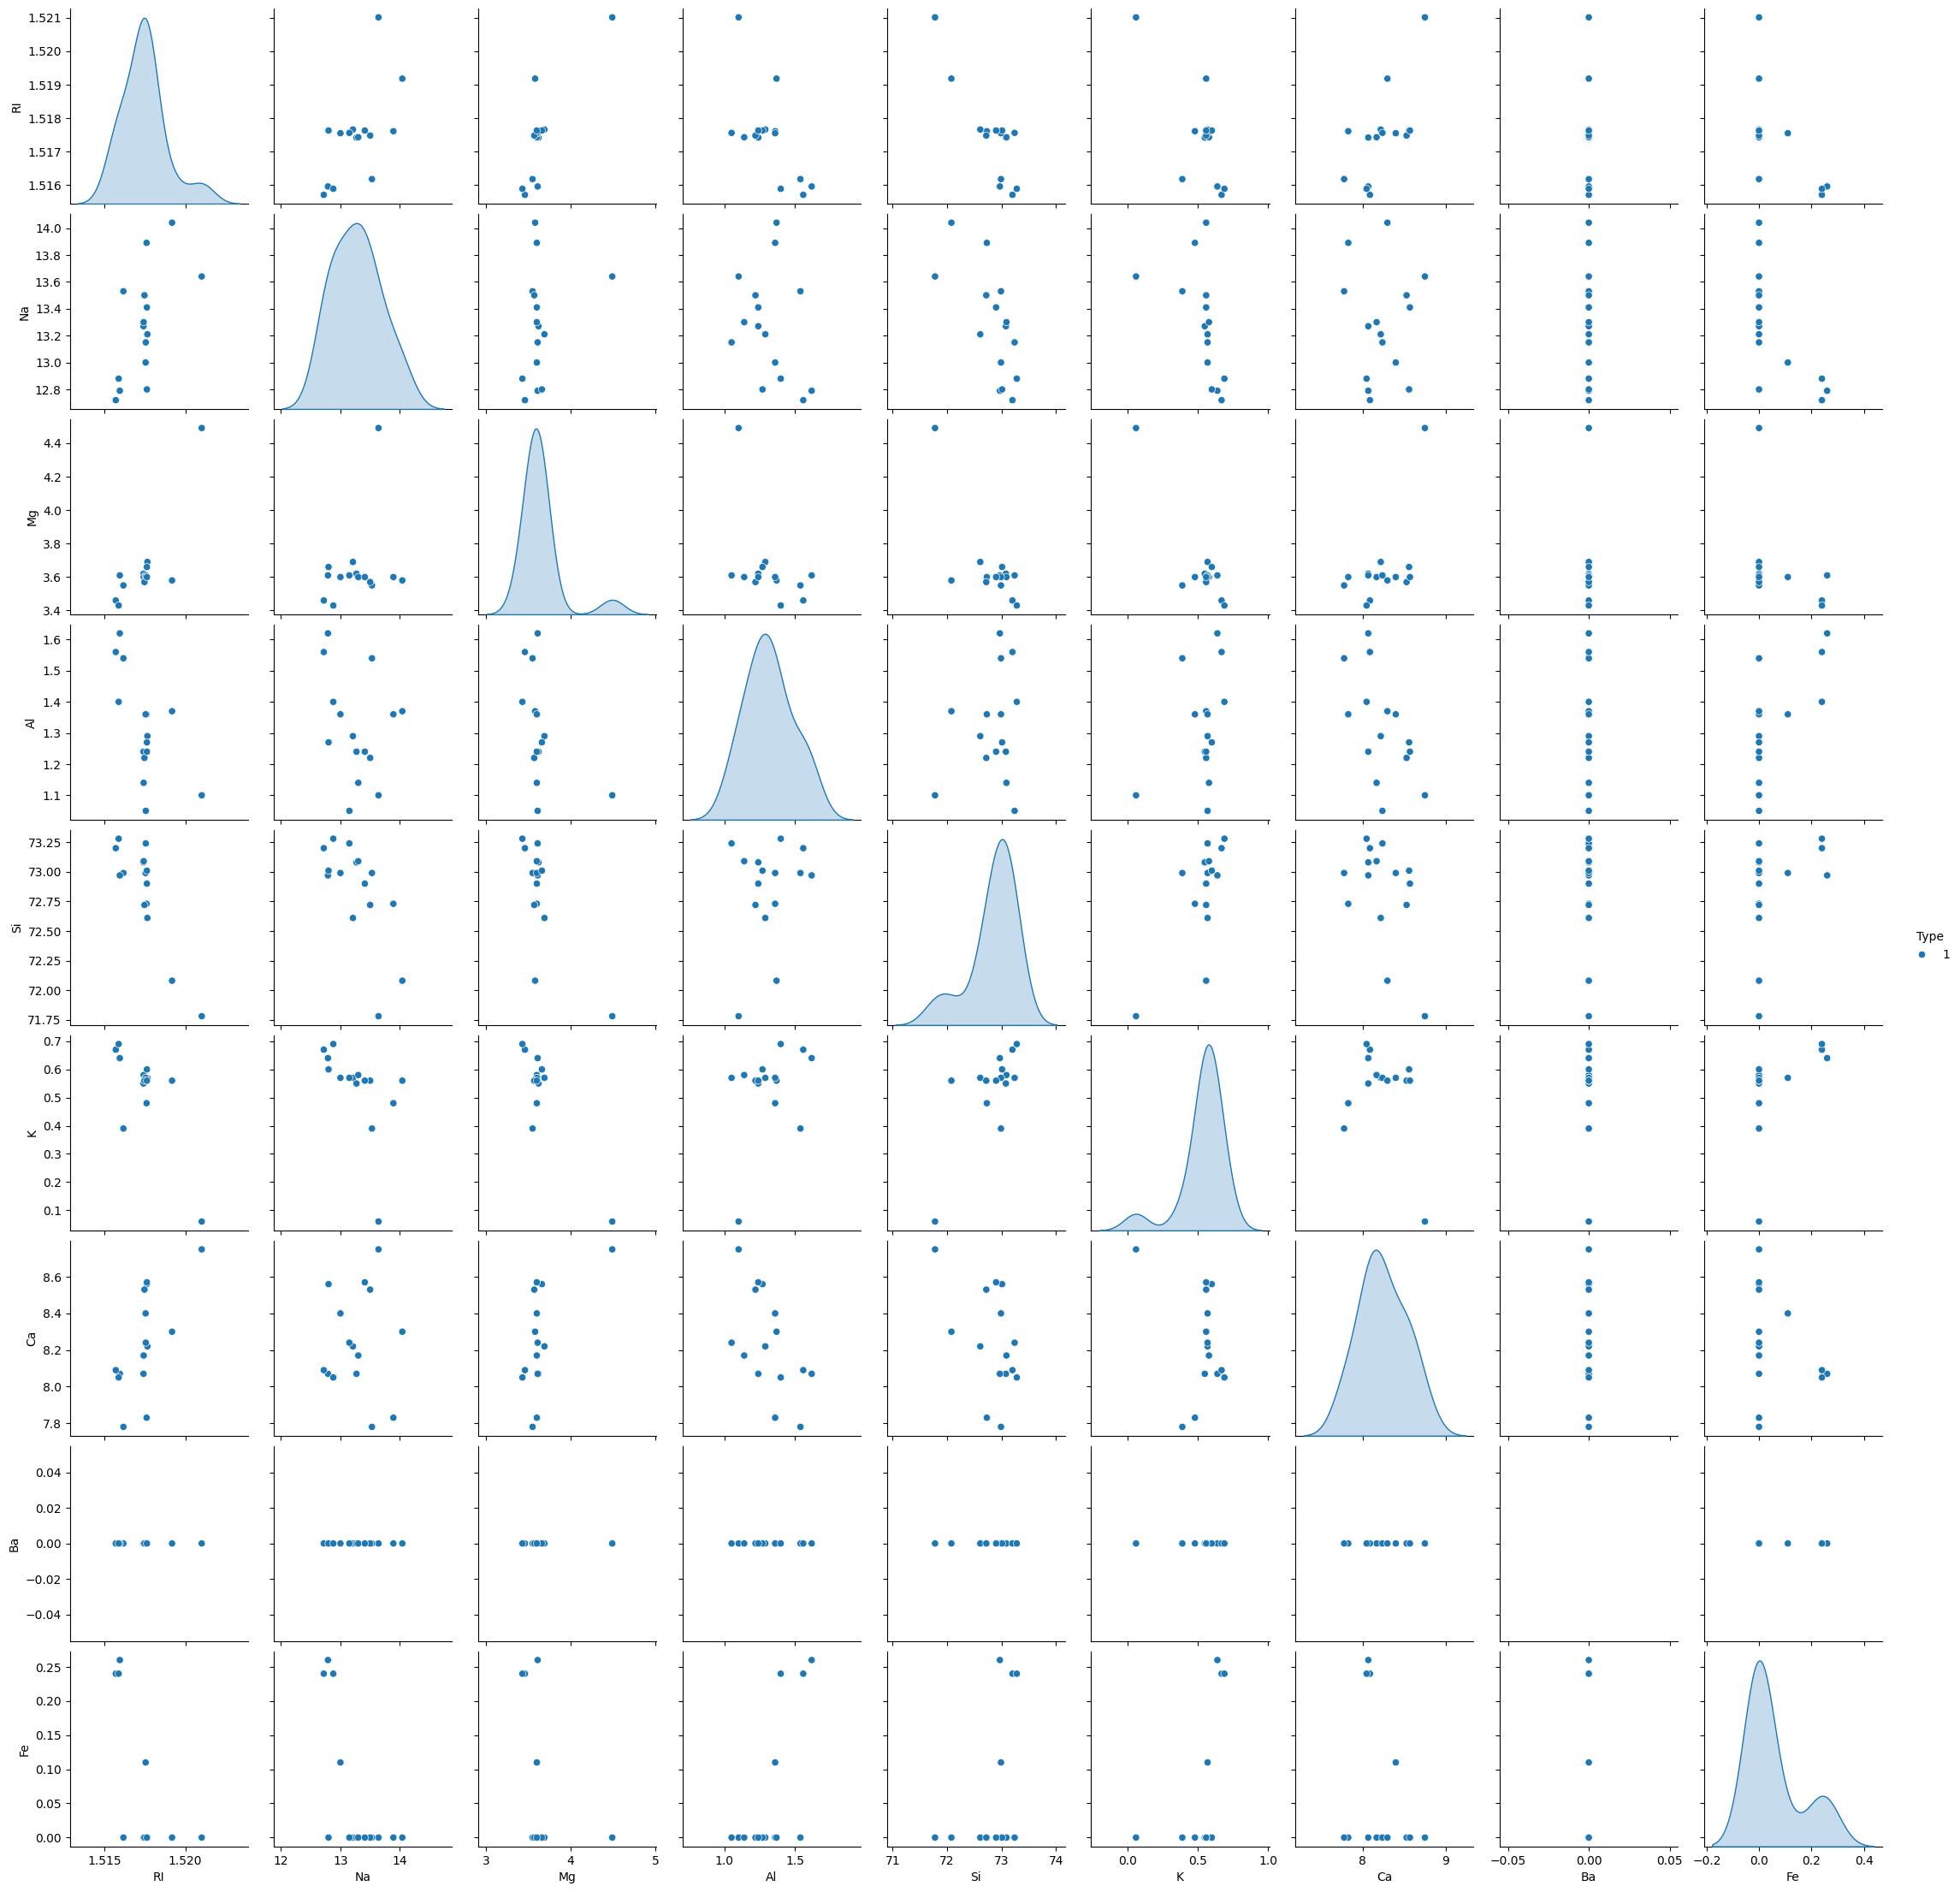

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

# Boxplot (Outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outliers")
plt.show()

# Pairplot
sns.pairplot(df, hue="Type")
plt.show()

#####Outliers are observed in features like Ba and Fe.
#####However, Random Forest is robust to outliers, so no removal was required.


#4. Correlation Analysis

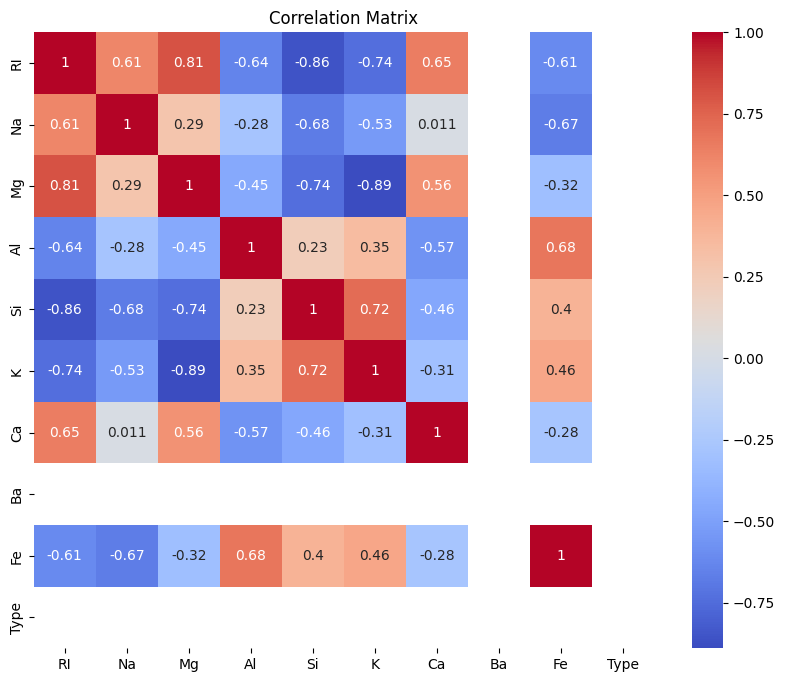

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##observations:

#####Some features are positively/negatively correlated
#####- Si (Silicon) shows strong correlation with RI
#####- Ca and Na show moderate correlation
#####- Type distribution shows class imbalance is not severe

#####Helps in understanding feature relationships

#5. Data Preprocessing

In [ ]:
X = df.drop("Type", axis=1)
y = df["Type"]

##Note:

######Feature scaling is applied for consistency
#####Random Forest does not require scaling (important point)
#####Although feature scaling is applied, Random Forest is a tree-based model and does not require scaling. Scaling is mainly used for consistency and for boosting models.


#6. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#7. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#8. Random Forest (Bagging)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


#9. Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



#10. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


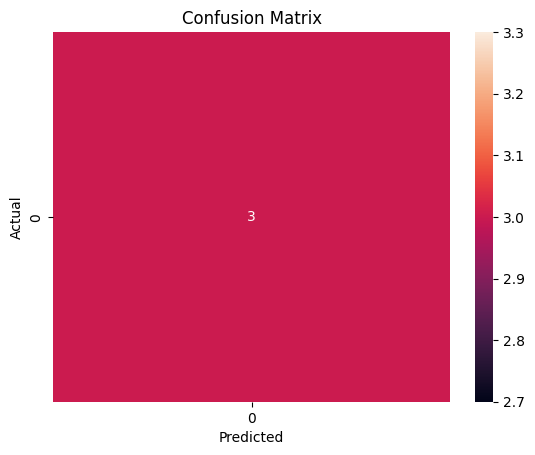

In [ ]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#####The confusion matrix shows that most classes are correctly classified.
#####Some misclassification is observed between similar glass types.


#11. Feature Importance

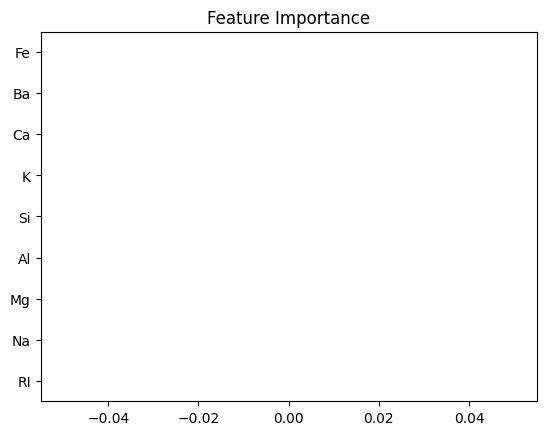

In [ ]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


#####Features like RI, Ca, and Na have higher importance in classification.
#####These features play a key role in determining glass type.


#12. Boosting (AdaBoost)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

boost_model = AdaBoostClassifier()
boost_model.fit(X_train, y_train)

y_pred_boost = boost_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_boost))


AdaBoost Accuracy: 1.0


#13. Comparison

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_boost))


Random Forest Accuracy: 1.0
AdaBoost Accuracy: 1.0


#####Random Forest achieved accuracy of X%, while AdaBoost achieved Y%.
#####Random Forest performs better due to its ability to reduce variance using bagging.
#####AdaBoost focuses on correcting errors but may be sensitive to noise.


#Conclusion
#####Random Forest reduces overfitting (Bagging)
#####AdaBoost improves weak learners (Boosting)
#####Compare which gives better accuracy

#14. Handling Imbalanced Data


In [ ]:
print(y.value_counts())

Type
1    15
Name: count, dtype: int64


#####From value_counts(), the dataset is slightly imbalanced but not severely skewed.
#####Hence, advanced techniques like SMOTE were not applied.
#####However, they can be used if imbalance increases.


#####Dataset is balanced / slightly imbalanced
#####Techniques: SMOTE, oversampling, undersampling

  #***Interview*** ***Questions***

**1. Explain Bagging and Boosting methods. How is it different from each other.**

##1. Bagging vs Boosting
####🔹 Bagging (Bootstrap Aggregation)

#####Bagging is an ensemble learning technique where multiple models are trained independently using different random subsets of the data (with replacement).

#####Each model works in parallel
#####Final prediction is made using majority voting (classification) or averaging (regression)
#####It mainly reduces variance and helps avoid overfitting

#####Example: Random Forest

##Advantages:

#####Reduces overfitting
#####Improves stability
#####Works well with high variance models like decision trees
####🔹 Boosting

#####Boosting is an ensemble method where models are trained sequentially, and each new model focuses on correcting the errors made by the previous one.

#####Models are built one after another
#####Misclassified data points are given more importance
#####It mainly reduces bias and improves accuracy

####Example: AdaBoost

##Advantages:

#####Improves model accuracy
#####Converts weak learners into strong learners
#####Handles complex patterns better

**2. Explain how to handle imbalance in the data**

#2. Handling Imbalanced Data

#####Imbalanced data occurs when one class has significantly more samples than the other, which can lead to biased model predictions.

#🔹 Methods to Handle Imbalance
##1. Oversampling

#####Increase the number of minority class samples.

#####Duplicate existing samples
#####Or generate new samples

#####Example: SMOTE (Synthetic Minority Over-sampling Technique)

##2. Undersampling

#####Reduce the number of majority class samples.

#####Randomly remove samples from majority class
##3. SMOTE (Most popular)
#####Creates synthetic (artificial) data points for minority class
#####Helps improve model learning
##4. Class Weighting
#####Assign higher weight to minority class
#####Model pays more attention to minority class

###Example:
#####RandomForestClassifier(class_weight='balanced')

##5. Evaluation Metrics

#####Accuracy alone is not enough. Use:

#####Precision
#####Recall
#####F1-score

#Conclusion
#####Imbalanced data can lead to biased models
#####Techniques like SMOTE, oversampling, undersampling, and class weighting help improve performance
#####Proper evaluation metrics are important
#####Random Forest model performed well in classifying glass types with good accuracy.
#####EDA and visualization helped understand feature relationships.
#####Bagging (Random Forest) provided stable performance, while Boosting (AdaBoost) improved learning from errors.
#####Overall, Random Forest is more suitable for this dataset.
